In [1]:
# 필요한 패키지 설치
!pip install -q transformers datasets
!pip install -U datasets fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 20.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyar

In [ ]:
import tensorflow as tf
from transformers import TFViTForImageClassification, ViTImageProcessor
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터셋 로드
dataset = load_dataset("cifar10")

# 2. Feature extractor
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# 3. 전처리 함수 정의
def transform(example):
    inputs = processor(images=example["img"], return_tensors="np")
    inputs["label"] = example["label"]
    return inputs

# 4. 소규모 샘플 데이터 변환 (속도 위해 1000개만 사용)
train_data = dataset["train"].select(range(1000)).map(transform)
val_data = dataset["test"].select(range(200)).map(transform)

# 5. TensorFlow Dataset 변환
def to_tf_dataset(data):
    return tf.data.Dataset.from_tensor_slices((
        {
            "pixel_values": np.stack([x["pixel_values"][0] for x in data]),
        },
        [x["label"] for x in data]
    )).batch(16)

train_tfds = to_tf_dataset(train_data)
val_tfds = to_tf_dataset(val_data)

# 6. 모델 로드
model = TFViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=10,
    from_pt=True,  # PyTorch 가중치를 TF로 변환
)

# 아래를 지우면 백본도 같이 학습
model.vit.trainable = False        # backbone freeze

# 7. 컴파일 및 학습
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(train_tfds, validation_data=val_tfds, epochs=3)

# 8. 정확도 시각화
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT (Hugging Face) on CIFAR-10")
plt.legend()
plt.grid(True)
plt.show()

TensorFlow + Transformers (TFViT) 버전

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['pooler.dense.weight', 'pooler.dense.bias']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTForImageClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
63/63 [==============================] - 97s 735ms/step - loss: 1.8604 - accuracy: 0.6610 - val_loss: 1.3500 - val_accuracy: 0.9050
Epoch 2/3
63/63 [==============================] - 43s 677ms/step - loss: 0.9161 - accuracy: 0.9590 - val_loss: 0.7658 - val_accuracy: 0.9250
Epoch 3/3
63/63 [==============================] - 43s 681ms/step - loss: 0.4674 - accuracy: 0.9850 - val_loss: 0.5110 - val_accuracy: 0.9400


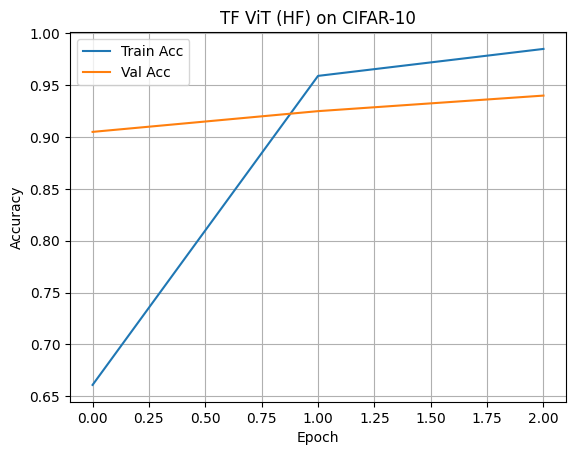

In [5]:
import tensorflow as tf
from transformers import TFViTForImageClassification, AutoImageProcessor
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# 1) 데이터셋 로드 (CIFAR-10)
dataset = load_dataset("cifar10")

# 2) Feature extractor / processor
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

# 3) 전처리 함수
def transform(example):
    proc = processor(images=example["img"], return_tensors="np")
    return {"pixel_values": proc["pixel_values"][0], "label": example["label"]}

# 4) 소규모 샘플 (속도용)
train_small = dataset["train"].select(range(1000)).map(transform)
val_small   = dataset["test"].select(range(200)).map(transform)

# 5) TF Dataset 변환
def to_tfds(data, batch_size=16, shuffle=False):
    x = np.stack([r["pixel_values"] for r in data])
    y = np.array([r["label"] for r in data], dtype=np.int64)
    ds = tf.data.Dataset.from_tensor_slices(({"pixel_values": x}, y))
    if shuffle:
        ds = ds.shuffle(len(y), reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_tfds = to_tfds(train_small, shuffle=True)
val_tfds   = to_tfds(val_small)

# 6) 모델 로드 (중요: from_pt=True 로 PT 가중치를 TF모델에 로드)
model = TFViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=10,
    from_pt=True,  # 파이토치 가중치를 TF로
)

# (옵션) 백본 동결하고 헤드만 학습하고 싶다면 아래 두 줄 사용
# model.vit.trainable = False
# print("Backbone trainable?", model.vit.trainable, "| Classifier trainable?", model.classifier.trainable)

# 7) 컴파일 & 학습
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
history = model.fit(train_tfds, validation_data=val_tfds, epochs=3)

# 8) 정확도 시각화
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("TF ViT (HF) on CIFAR-10")
plt.legend(); plt.grid(True); plt.show()